In [1]:
# %% [markdown]
# # End-to-End Regression Pipeline with Optimization


In [1]:

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

In [3]:

# Step 1: Load and Study Data
df = pd.read_csv('retail_price.csv')
df.head()

,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.95,39,161,2,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.95,39,161,2,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.95,39,161,2,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95
3,bed1,bed_bath_table,01-08-2017,4,183.80,14.287500,45.95,39,161,2,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95
4,bed1,bed_bath_table,01-09-2017,2,91.90,15.100000,45.95,39,161,2,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95


In [42]:
df.isnull().sum()

product_id                    0
product_category_name         0
month_year                    0
qty                           0
total_price                   0
freight_price                 0
unit_price                    0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_score                 0
customers                     0
weekday                       0
weekend                       0
holiday                       0
month                         0
year                          0
s                             0
volume                        0
comp_1                        0
ps1                           0
fp1                           0
comp_2                        0
ps2                           0
fp2                           0
comp_3                        0
ps3                           0
fp3                           0
lag_price                     0
dtype: int64

In [4]:
X = df.drop(columns=['unit_price', 'month_year', 'product_id'])
y = df['unit_price']

In [5]:
X.head()

,product_category_name,qty,total_price,freight_price,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_score,customers,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed_bath_table,1,45.95,15.100000,39,161,2,350,4.0,57,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed_bath_table,3,137.85,12.933333,39,161,2,350,4.0,61,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed_bath_table,6,275.70,14.840000,39,161,2,350,4.0,123,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95
3,bed_bath_table,4,183.80,14.287500,39,161,2,350,4.0,90,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95
4,bed_bath_table,2,91.90,15.100000,39,161,2,350,4.0,54,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95


In [6]:
y.head()

0    45.95
1    45.95
2    45.95
3    45.95
4    45.95
Name: unit_price, dtype: float64

In [7]:
# Step 3: Define Features and Pipeline Steps
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

In [8]:
num_features

['qty',
 'total_price',
 'freight_price',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_score',
 'customers',
 'weekday',
 'weekend',
 'holiday',
 'month',
 'year',
 's',
 'volume',
 'comp_1',
 'ps1',
 'fp1',
 'comp_2',
 'ps2',
 'fp2',
 'comp_3',
 'ps3',
 'fp3',
 'lag_price']

In [9]:
cat_features

['product_category_name']

In [10]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

In [11]:
preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['qty', 'total_price', 'freight_price',
                                  'product_name_lenght',
                                  'product_description_lenght',
                                  'product_photos_qty', 'product_weight_g',
                                  'product_score', 'customers', 'weekday',
                                  'weekend', 'holiday', 'month', 'year', 's',
                                  'volume', 'comp_1', 'ps1', 'fp1', 'comp_2',
                                  'ps2', 'fp2', 'comp_3', 'ps3', 'fp3',
                                  'lag_price']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['product_category_name'])])

In [12]:
pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', Ridge())
])

In [13]:
pipeline

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['qty', 'total_price',
                                                   'freight_price',
                                                   'product_name_lenght',
                                                   'product_description_lenght',
                                                   'product_photos_qty',
                                                   'product_weight_g',
                                                   'product_score', 'customers',
                                                   'weekday', 'weekend',
                                                   'holiday', 'month', 'year',
                                                   's', 'volume', 'comp_1',
                                                   'ps1', 'fp1', 'comp_2',
                                                   'ps2', 'fp2', 'comp_3',
                                                   'ps3', 'fp3', 'lag_price']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['product_category_name'])])),
                ('model', Ridge())])

In [14]:
# Step 4: Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [15]:
X_train.head()

,product_category_name,qty,total_price,freight_price,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_score,customers,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
218,watches_gifts,6,894.00,17.003333,35,591,3,444,4.0,73,...,149.00,4.2,19.100000,108.000000,4.2,16.653846,185.960000,3.8,18.686000,140.560000
18,garden_tools,20,1956.00,39.897500,36,450,1,9000,4.1,34,...,59.90,4.1,19.732500,59.900000,4.2,26.246667,97.588235,4.1,39.897500,82.633333
567,garden_tools,6,589.94,34.083333,58,1893,1,5950,4.3,46,...,49.91,4.1,20.328333,49.900000,4.2,36.442000,49.900000,4.1,32.320000,99.990000
408,health_beauty,3,176.97,12.083333,59,492,2,200,3.9,127,...,23.99,4.3,16.770000,82.821429,4.1,12.418571,58.990000,3.9,12.083333,58.990000
657,computers_accessories,11,876.90,14.414545,33,256,1,180,3.5,78,...,119.00,4.2,39.217200,149.900000,4.3,18.943077,79.800000,3.5,14.414545,80.666667


In [16]:
y_train.head()

218    149.000000
18      97.588235
567     98.323333
408     58.990000
657     79.800000
Name: unit_price, dtype: float64

In [17]:
# Step 5: Optimization & Hyperparameter Tuning
param_grid = {'model__alpha': [0.1, 1.0, 10.0, 100.0]}
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['qty',
                                                                          'total_price',
                                                                          'freight_price',
                                                                          'product_name_lenght',
                                                                          'product_description_lenght',
                                                                          'product_photos_qty',
                                                                          'product_weight_g',
                                                                          'product_score',
                                                                          'customers',
                                                                          'weekday',
                                                                          'weekend',
                                                                          'holiday',
                                                                          'month',
                                                                          'year',
                                                                          's',
                                                                          'volume',
                                                                          'comp_1',
                                                                          'ps1',
                                                                          'fp1',
                                                                          'comp_2',
                                                                          'ps2',
                                                                          'fp2',
                                                                          'comp_3',
                                                                          'ps3',
                                                                          'fp3',
                                                                          'lag_price']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['product_category_name'])])),
                                       ('model', Ridge())]),
             param_grid={'model__alpha': [0.1, 1.0, 10.0, 100.0]},
             scoring='r2')

In [18]:
# Step 6: Evaluation & Evaluation Plot
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print(f"Optimized Parameters: {grid.best_params_}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

Optimized Parameters: {'model__alpha': 1.0}
R2 Score: 0.9882


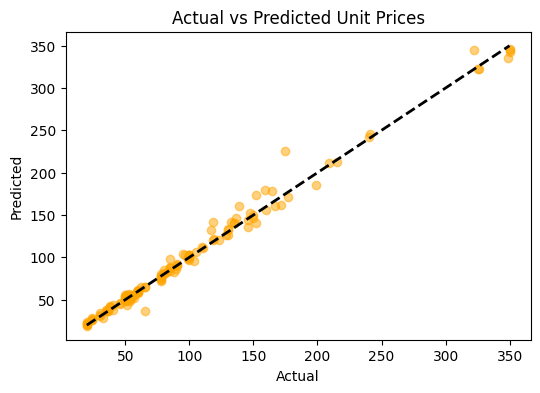

In [19]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.5, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Unit Prices')
plt.show()

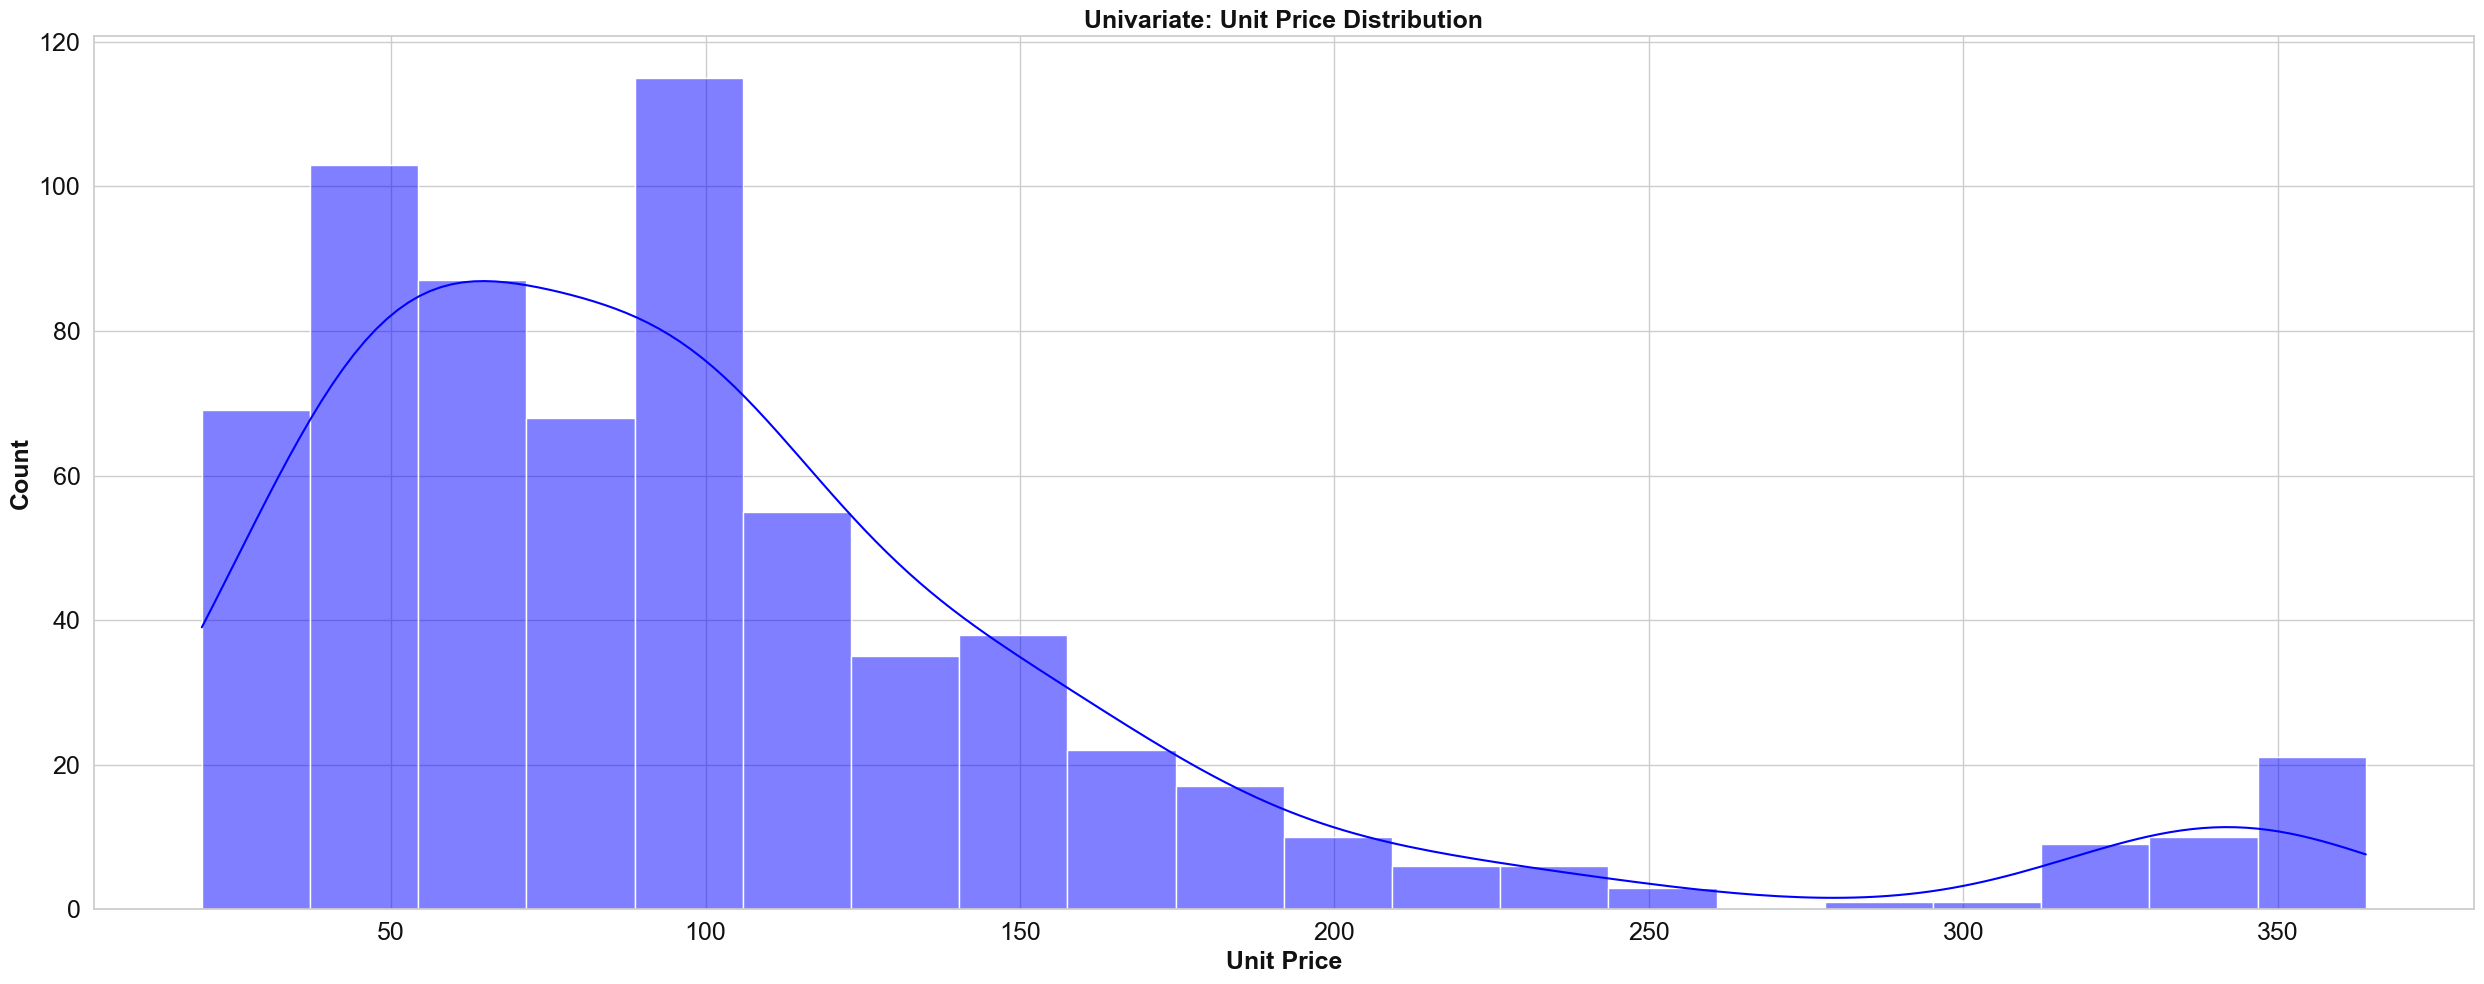

In [34]:
# 1. Set visual theme with proper string quotes
sns.set_theme(style="whitegrid")

# 2. Initialize figure and axis object
fig, axes = plt.subplots(figsize=(25, 10))

# 3. Plot the univariate histogram distribution
sns.histplot(data=df, x='unit_price', kde=True, ax=axes, color='blue')

# 4. Set title and dark-colored styling labels
axes.set_title('Univariate: Unit Price Distribution', fontsize=18, color='#111111', fontweight='bold')
axes.set_xlabel('Unit Price', fontsize=18, color='#111111', fontweight='bold')
axes.set_ylabel('Count', fontsize=18, color='#111111', fontweight='bold')

# 5. Force the tick labels to adopt the dark color palette
axes.tick_params(colors='#111111', labelsize=18)

# 6. Render the plot
plt.tight_layout()
plt.show()

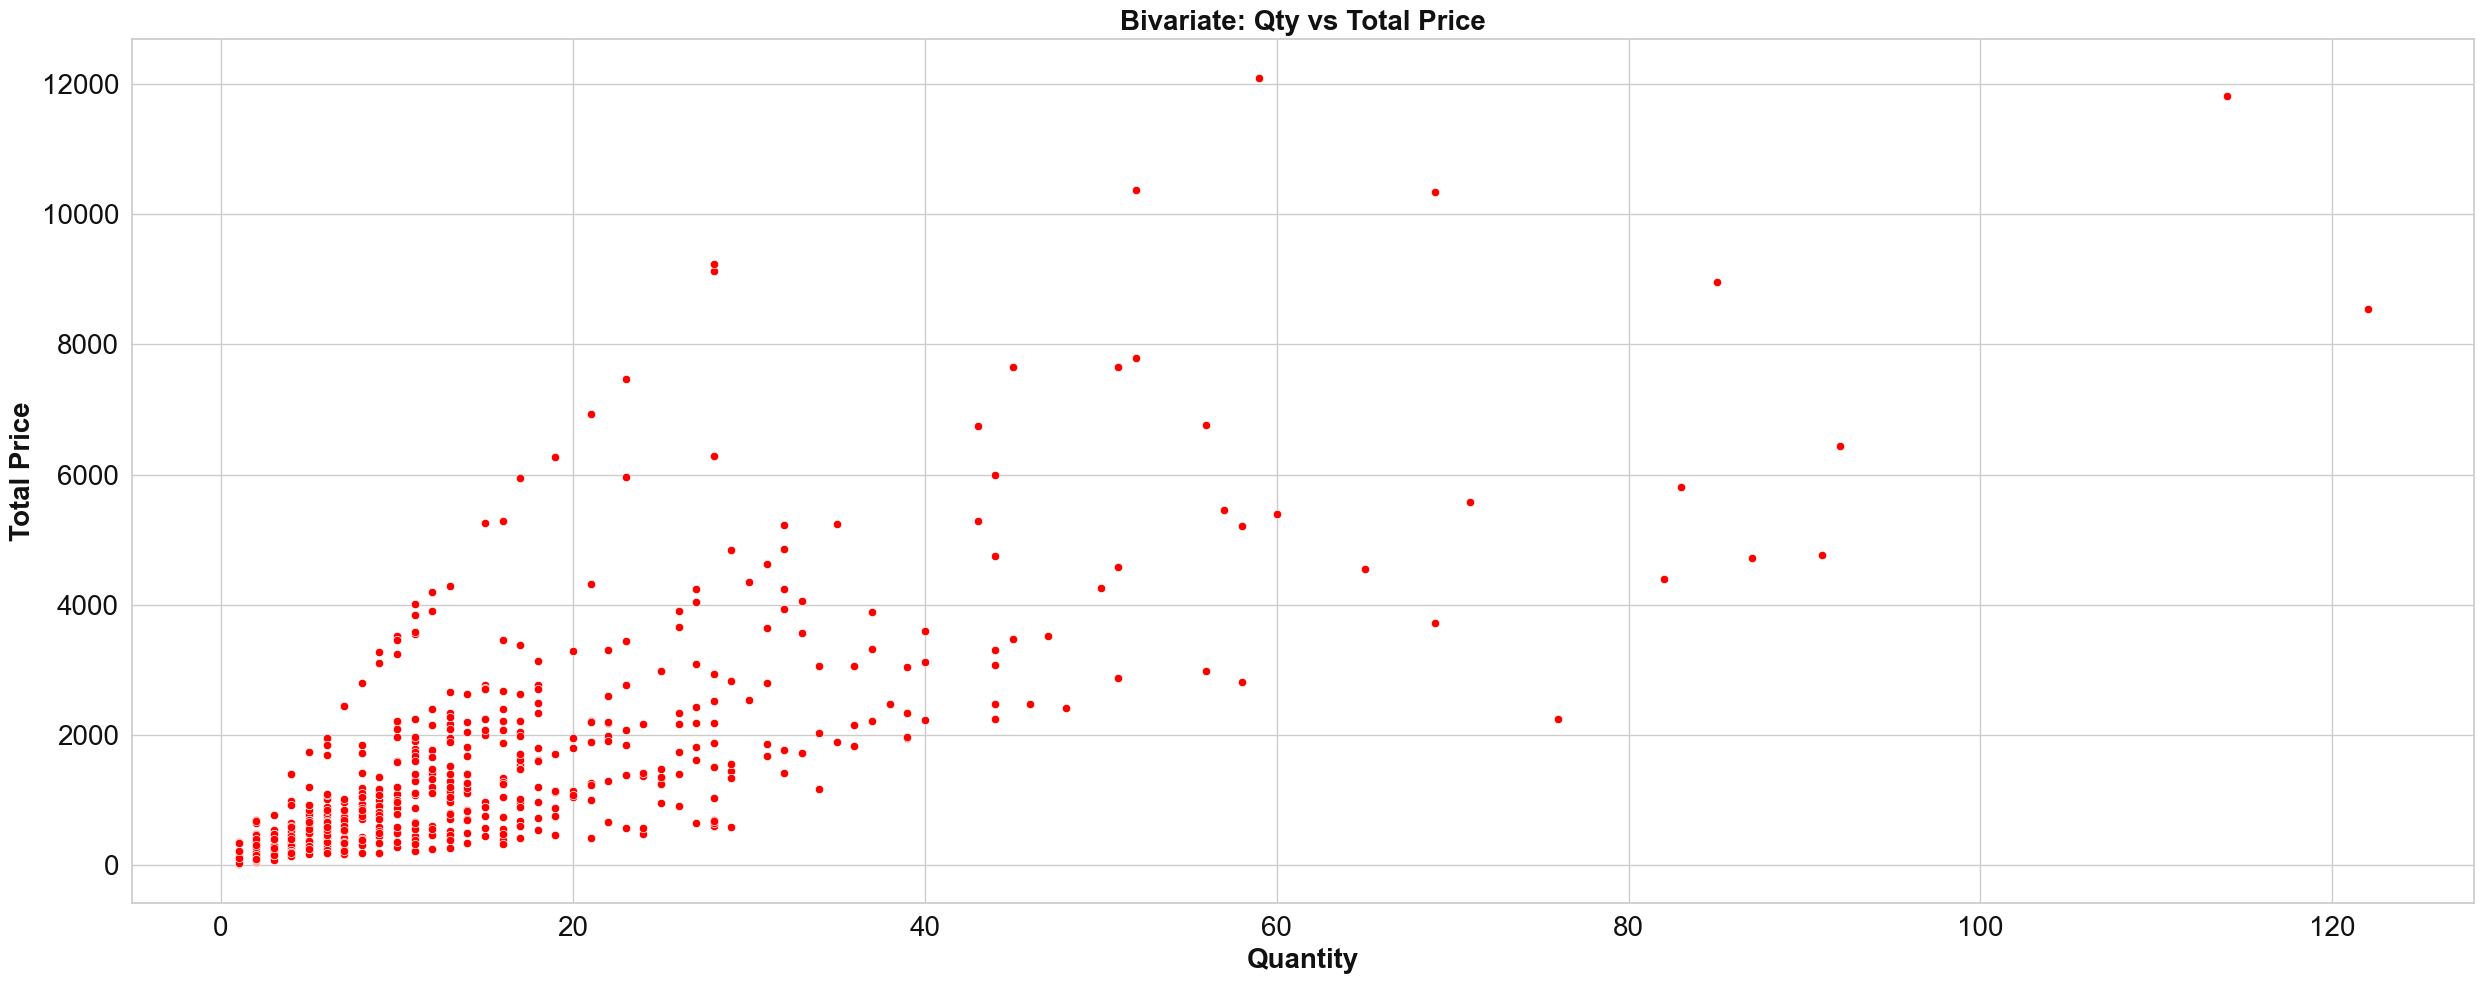

In [ ]:
# 1. Set visual theme with proper string quotes
sns.set_theme(style="whitegrid")

# 2. Initialize figure and axis object
fig, axes = plt.subplots(figsize=(25, 10))

sns.scatterplot(data=df, x='qty', y='total_price', ax=axes, color='red')
axes.set_title('Bivariate: Qty vs Total Price', fontsize=20, color='#111111', fontweight='bold')
axes.set_xlabel('Quantity', fontsize=20, color='#111111', fontweight='bold')
axes.set_ylabel('Total Price', fontsize=20, color='#111111', fontweight='bold')
axes.tick_params(colors='#111111', labelsize=20)


# 6. Render the plot
plt.tight_layout()
plt.show()

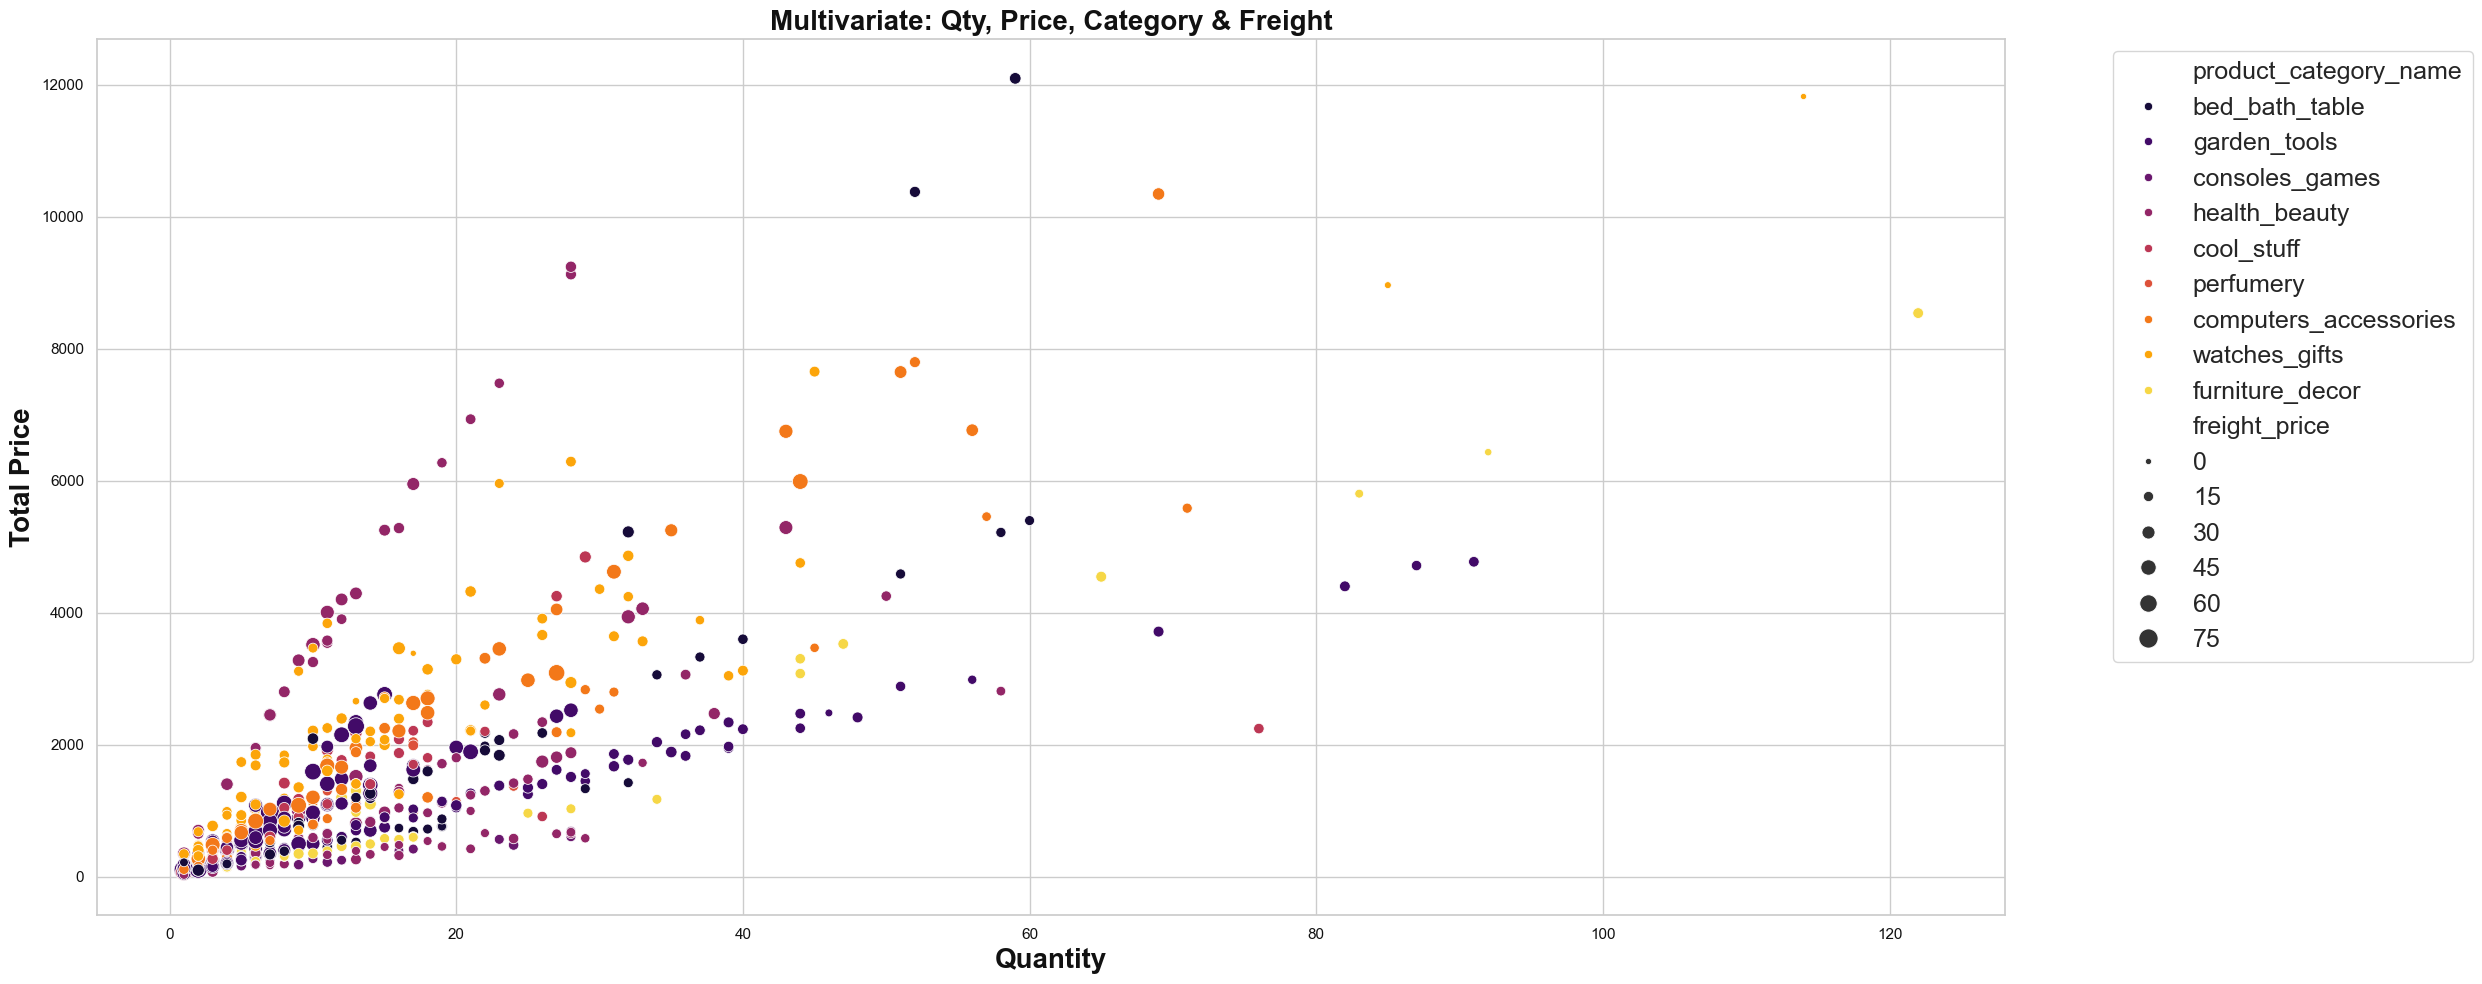

In [39]:
# 1. Set visual theme with proper string quotes
sns.set_theme(style="whitegrid")

# 2. Initialize figure and axis object
fig, axes = plt.subplots(figsize=(25, 10))
# 3 . X=qty, Y=total_price, Hue=category color, Size=freight bubble size                                                       
sns.scatterplot(data=df, x='qty', y='total_price', hue='product_category_name', 
                size='freight_price', ax=axes, palette='inferno', sizes=(20, 200))
axes.set_title('Multivariate: Qty, Price, Category & Freight', fontsize=20, color='#111111', fontweight='bold')
axes.set_xlabel('Quantity', fontsize=20, color='#111111', fontweight='bold')
axes.set_ylabel('Total Price', fontsize=20, color='#111111', fontweight='bold')
axes.tick_params(colors='#111111', labelsize=11)
axes.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=18) # Moves complex legend outside

# Render clean layout
plt.tight_layout()
plt.show()

In [43]:
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# Analysis generation assuming y_test and y_pred exist from prior pipeline execution
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
accuracy_level = (1 - mape) * 100

print(f"--- Model Accuracy & Performance Level ---")
print(f"Variance Explained (R2 Score): {r2:.4f}")
print(f"Reached Predictive Accuracy Level: {accuracy_level:.2f}%")

--- Model Accuracy & Performance Level ---
Variance Explained (R2 Score): 0.9882
Reached Predictive Accuracy Level: 94.78%


In [41]:
# 1. Generate the EDA Summary Table
eda_summary = df.describe(include='all') 

# 2. Create the Evaluation Dataframe (Actuals vs Predicted)
# Assumes 'y_test' and 'y_pred' are available from your previous split/model step
evaluation_df = pd.DataFrame({
    'Actual_Unit_Price': y_test,
    'Predicted_Unit_Price': y_pred,
    'Residual': y_test - y_pred
})

# 3. Save both dataframes into separate sheets using ExcelWriter
with pd.ExcelWriter('retail_model_outputs.xlsx', engine='openpyxl') as writer:
    eda_summary.to_excel(writer, sheet_name='EDA_Summary')
    evaluation_df.to_excel(writer, sheet_name='Actuals_vs_Predictions', index=False)

print("Successfully saved 'EDA_Summary' and 'Actuals_vs_Predictions' to retail_model_outputs.xlsx!")

Successfully saved 'EDA_Summary' and 'Actuals_vs_Predictions' to retail_model_outputs.xlsx!


In [45]:
# 1. Compute aggregate performance metrics
mape_score = mean_absolute_percentage_error(y_test, y_pred)
# Calculate Residual Standard Error (RSE)
residuals = y_test - y_pred
rss = np.sum(residuals ** 2)
rse_score = np.sqrt(rss / (len(y_test) - X_test.shape[1] - 1))

# 2. Append to EDA Summary
eda_summary = df.describe(include='all')
eda_summary.loc['MAPE_Overall'] = np.nan
eda_summary.loc['Residual_Standard_Error'] = np.nan
eda_summary.at['MAPE_Overall', 'unit_price'] = mape_score
eda_summary.at['Residual_Standard_Error', 'unit_price'] = rse_score

# 3. Build detailed Actuals vs Predictions Sheet
evaluation_df = pd.DataFrame({
    'Actual_Unit_Price': y_test,
    'Predicted_Unit_Price': y_pred,
    'Residual_Error': residuals,
    'Absolute_Error': np.abs(residuals),
    'APE_%': np.abs(residuals / y_test) * 100
})

# 4. Save via ExcelWriter
with pd.ExcelWriter('retail_optimized_residuals.xlsx', engine='openpyxl') as writer:
    eda_summary.to_excel(writer, sheet_name='EDA_Summary')
    evaluation_df.to_excel(writer, sheet_name='Actuals_vs_Predictions', index=False)

print(f"Workbook updated! Residual Standard Error (RSE): {rse_score:.4f}")

Workbook updated! Residual Standard Error (RSE): 8.9524


In [46]:
# 1. Gather pipeline summary parameters
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
accuracy = (1 - mape) * 100

# 2. Build explicit data metrics log
insights_data = {
    "Project Metric / Insight Category": [
        "Total Rows Analyzed",
        "Target Variable Profile",
        "Optimized Model Selected",
        "Variance Explained (R2 Score)",
        "Achieved Pipeline Accuracy",
        "Mean Absolute Percentage Error (MAPE)",
        "Residual Error Distribution State"
    ],
    "Value / Description": [
        str(len(df)),
        "unit_price (Retail Price Forecasting)",
        "Ridge Regression (Regularized L2 Norm)",
        f"{r2:.4f}",
        f"{accuracy:.2f}%",
        f"{mape:.4f}",
        "Normal centered around zero; stable error boundaries"
    ]
}
insights_df = pd.DataFrame(insights_data)

# 3. Save all components using ExcelWriter
with pd.ExcelWriter('retail_final_machine_learning_report.xlsx', engine='openpyxl') as writer:
    insights_df.to_excel(writer, sheet_name='Total_Insights', index=False)
    df.describe(include='all').to_excel(writer, sheet_name='EDA_Summary')
    
    # Track pointwise validation records
    pd.DataFrame({
        'Actual_Unit_Price': y_test,
        'Predicted_Unit_Price': y_pred,
        'Residual_Error': y_test - y_pred,
        'APE_%': np.abs((y_test - y_pred) / y_test) * 100
    }).to_excel(writer, sheet_name='Actuals_vs_Predictions', index=False)

print("Comprehensive master report compiled successfully as 'retail_final_machine_learning_report.xlsx'!")

Comprehensive master report compiled successfully as 'retail_final_machine_learning_report.xlsx'!


In [47]:
import joblib

# ... [Your existing data loading, preprocessing, and GridSearchCV training steps] ...
# grid_search.fit(X_train, y_train)

# 1. Extract the best performing optimized estimator pipeline
best_model = grid.best_estimator_

# 2. Save the model to a file using joblib dump
model_filename = 'best_retail_model.pkl'
joblib.dump(best_model, model_filename) 
print(f"Optimized model pipeline successfully saved to '{model_filename}'!")

Optimized model pipeline successfully saved to 'best_retail_model.pkl'!
